In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from tqdm import tqdm
import math

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [3]:
class MedicalDataset(Dataset):

    def __init__(self, root_dir, img_size=224):

        self.paths = []
        self.labels = []

        for label, folder in enumerate(["NORMAL", "PNEUMONIA"]):
            folder_path = os.path.join(root_dir, folder)

            for img_name in os.listdir(folder_path):
                self.paths.append(os.path.join(folder_path, img_name))
                self.labels.append(label)

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((img_size, img_size))
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = cv2.imread(self.paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        clean = self.transform(img)

        # simple corruption (noise)
        noise = torch.randn_like(clean) * 0.1
        corrupted = torch.clamp(clean + noise, 0, 1)

        return corrupted, clean, self.labels[idx]

In [4]:
DATA_PATH = r"D:\Image Recognition\chest_xray\train"

dataset = MedicalDataset(DATA_PATH)
loader = DataLoader(dataset, batch_size=8, shuffle=True)

In [5]:
class Block(nn.Module):
    def __init__(self,a,b):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(a,b,3,1,1),
            nn.BatchNorm2d(b),
            nn.ReLU())
    def forward(self,x): return self.net(x)

class ProcessingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            Block(3,64),Block(64,64),
            nn.MaxPool2d(2),
            Block(64,128),Block(128,128),
            nn.Upsample(scale_factor=2),
            Block(128,64),
            nn.Conv2d(64,3,3,1,1),
            nn.Sigmoid())
    def forward(self,x): return self.net(x)


In [6]:
teacher = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# modify for 2 classes
teacher.fc = nn.Linear(teacher.fc.in_features, 2)

teacher = teacher.to(device)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(teacher.parameters(), lr=1e-4)

for epoch in range(5):

    total_loss = 0

    for _, clean, label in tqdm(loader):

        clean = clean.to(device)
        label = label.to(device)

        pred = teacher(clean)
        loss = criterion(pred, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss/len(loader):.4f}")



100%|██████████| 652/652 [03:54<00:00,  2.78it/s]


Epoch 1 Loss: 0.1156


100%|██████████| 652/652 [03:01<00:00,  3.60it/s]


Epoch 2 Loss: 0.0386


100%|██████████| 652/652 [02:55<00:00,  3.71it/s]


Epoch 3 Loss: 0.0345


100%|██████████| 652/652 [02:57<00:00,  3.67it/s]


Epoch 4 Loss: 0.0146


100%|██████████| 652/652 [03:05<00:00,  3.51it/s]

Epoch 5 Loss: 0.0114


In [8]:
lambda_values = [0, 0.01, 0.1, 0.5, 1]

image_loss_fn = nn.MSELoss()
class_loss_fn = nn.CrossEntropyLoss()

normalize = transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
)

for lam in lambda_values:

    print(f"\nTraining λ = {lam}")

    model = ProcessingNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    for epoch in range(5):

        for corrupted, clean, label in tqdm(loader):

            corrupted = corrupted.to(device)
            clean = clean.to(device)
            label = label.to(device)

            restored = model(corrupted)

            img_loss = image_loss_fn(restored, clean)

            pred = teacher(normalize(restored))
            recog_loss = class_loss_fn(pred, label)

            loss = img_loss + lam * recog_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    torch.save(model.state_dict(), f"medical_RA_lambda_{lam}.pth")


Training λ = 0


100%|██████████| 652/652 [03:08<00:00,  3.45it/s]



Training λ = 0.01


100%|██████████| 652/652 [03:14<00:00,  3.35it/s]



Training λ = 0.1


100%|██████████| 652/652 [03:14<00:00,  3.35it/s]



Training λ = 0.5


100%|██████████| 652/652 [03:24<00:00,  3.19it/s]



Training λ = 1


100%|██████████| 652/652 [03:11<00:00,  3.40it/s]


In [9]:
def evaluate(model):

    correct = 0
    total = 0

    with torch.no_grad():

        for corrupted, clean, label in loader:

            corrupted = corrupted.to(device)
            clean = clean.to(device)
            label = label.to(device)

            restored = model(corrupted)

            pred = teacher(normalize(restored)).argmax(1)

            correct += (pred == label).sum().item()
            total += label.size(0)

    return 100 * correct / total

In [10]:
results = {}

for lam in lambda_values:

    model = ProcessingNet().to(device)
    model.load_state_dict(torch.load(f"medical_RA_lambda_{lam}.pth", map_location=device))
    model.eval()

    acc = evaluate(model)
    results[f"RA λ={lam}"] = acc

print("\n===== MEDICAL RESULTS =====\n")
for k,v in results.items():
    print(f"{k:10s}: {v:.2f}%")


===== MEDICAL RESULTS =====

RA λ=0    : 99.50%
RA λ=0.01 : 99.21%
RA λ=0.1  : 99.14%
RA λ=0.5  : 98.45%
RA λ=1    : 99.02%


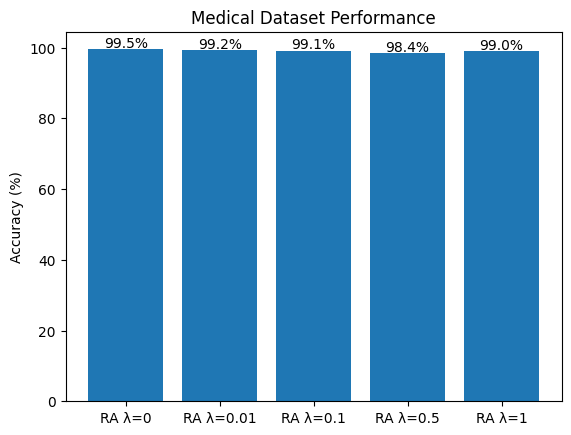

In [11]:
names = list(results.keys())
values = list(results.values())

plt.bar(names, values)
plt.ylabel("Accuracy (%)")
plt.title("Medical Dataset Performance")

for i,v in enumerate(values):
    plt.text(i, v+0.5, f"{v:.1f}%", ha='center')

plt.show()

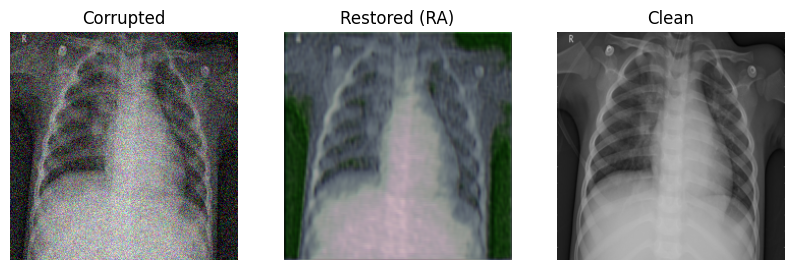


===== PREDICTION =====
Actual Label   : PNEUMONIA
Predicted Label: PNEUMONIA


In [14]:
import random

# pick random sample
idx = random.randint(0, len(dataset)-1)

corrupted, clean, label = dataset[idx]

corrupted = corrupted.unsqueeze(0).to(device)
clean = clean.unsqueeze(0).to(device)

# load best model (choose best lambda)
best_model = ProcessingNet().to(device)
best_model.load_state_dict(torch.load("medical_RA_lambda_0.1.pth", map_location=device))
best_model.eval()

# forward
with torch.no_grad():
    restored = best_model(corrupted)

    pred = teacher(normalize(restored)).argmax(1).item()

# labels
classes = ["NORMAL", "PNEUMONIA"]

# convert to display
def show(img):
    return img.squeeze().permute(1,2,0).cpu().numpy()

# plot
plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(show(corrupted))
plt.title("Corrupted")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(show(restored))
plt.title("Restored (RA)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(show(clean))
plt.title("Clean")
plt.axis("off")

plt.show()

print("\n===== PREDICTION =====")
print("Actual Label   :", classes[label])
print("Predicted Label:", classes[pred])